<a href="https://colab.research.google.com/github/kmkarakaya/Deep-Learning-Tutorials/blob/master/Gemma4_(E2B)_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Fri Apr 10 20:43:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


# Finetuning Gemma4 with Unsloth

[Watch on YouTube in Turkish](https://youtube.com/live/t6a5BNEHzwM?feature=share).

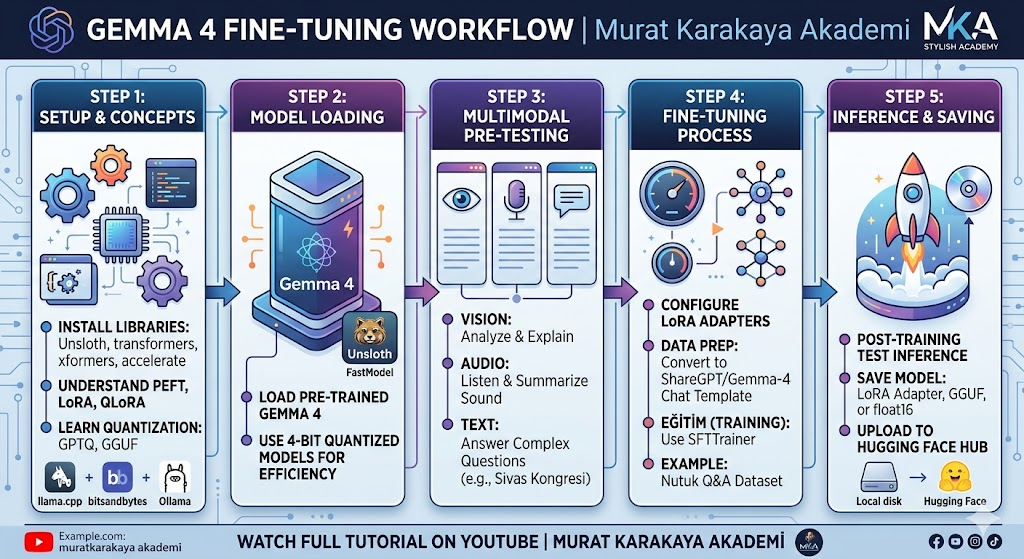

## Finetuning

### LLM Models: Foundation Models vs. Instruct Models
Foundation models and instruct models represent two key stages in the development of Large Language Models (LLMs). Here's how they differ and their roles in training, fine-tuning, and related concepts:

### Pre-Training and Fine-Tuning:
* Pre-training creates a "general-purpose brain" capable of understanding and generating human-like text.
* Fine-tuning customizes that brain for specific tasks, domains, or behaviors.


Example Workflow with LLaMA:

* Pre-Trained Model: The LLaMA model is pre-trained on diverse datasets by Meta.
* Fine-Tuned Model: Use Unsloth or other PEFT methods to fine-tune LLaMA for a chatbot that understands financial advice.

* The resulting fine-tuned model is then deployed using llama.cpp or its Python interface (llama-cpp-python) for efficient inference.

By leveraging pre-training and fine-tuning, we maximize the efficiency of LLMs, making them versatile and adaptable for a wide range of applications.

### Key Concepts:

* **Quantization** reduces model size and computational cost.
* **GPTQ** is a powerful quantization method tailored for GPT-based models, enabling fast and efficient inference.

* **PEFT** is a broad category of fine-tuning methods like LoRA and QLoRA.
* **LoRA** fine-tunes models by modifying only a small part of them.
* **QLoRA** combines quantization with LoRA for extra efficiency.

* **GGML** optimizes model performance in low-resource environments.
* **GGUF** is a format for efficient model storage and deployment.

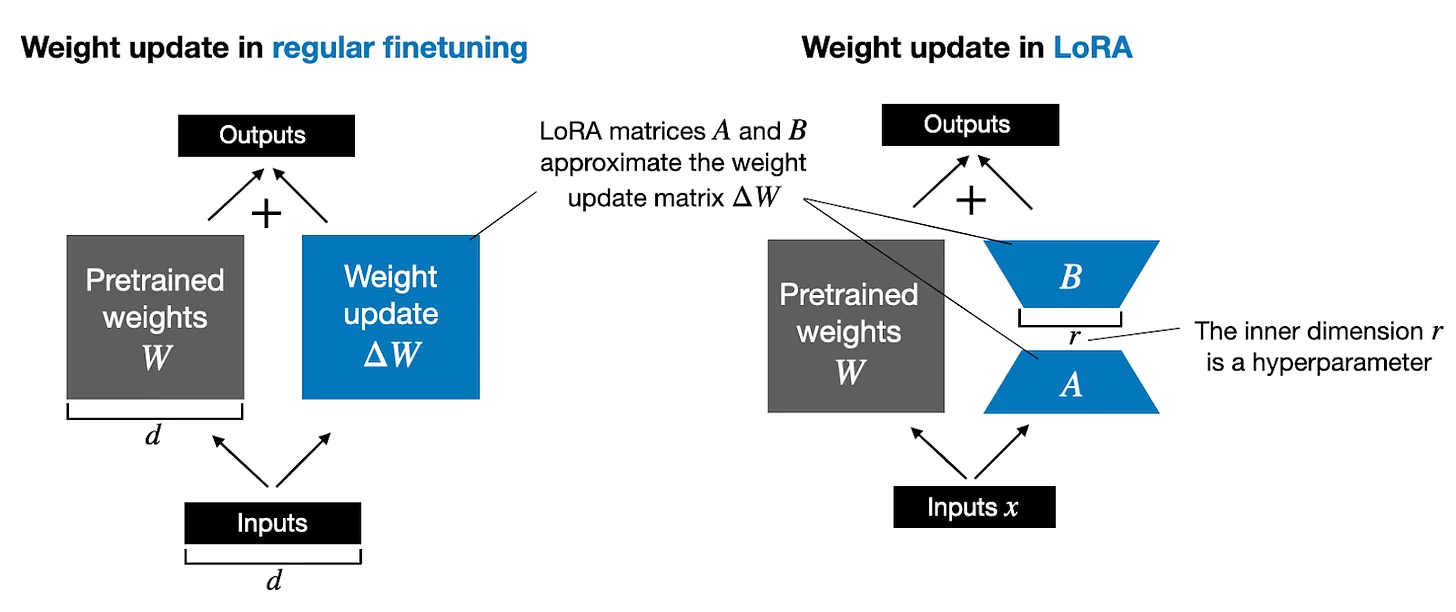

### Key Libraries in Fine-Tuning:
* **llama.cpp**: Acts as the ***foundational backend*** for running and processing LLaMA models efficiently. It is used during both the fine-tuning process (if adapted by tools like Unsloth) and for inference.
* **Unsloth**: Builds on llama.cpp to provide fine-tuning capabilities, particularly focusing on parameter-efficient methods like LoRA. It ensures that ***fine-tuning*** LLaMA models is computationally ***feasible and memory-efficient***.
* **llama-cpp-python**: Serves as the Python interface for llama.cpp, allowing integration into Python workflows. While it doesn't fine-tune models itself, it can:
 * Be used during fine-tuning to interact with llama.cpp.
 * Load and run fine-tuned models for evaluation or deployment.

* **bitsandbytes**:The bitsandbytes library is a powerful tool that optimizes the training, fine-tuning, and deployment of Large Language Models (LLMs) by significantly reducing memory and computational requirements.
 * It achieves this through advanced techniques like mixed-precision training, custom CUDA kernels, and efficient quantization methods.
 * By allowing the use of 8-bit or even 4-bit precision instead of the standard 16-bit or 32-bit formats, bitsandbytes drastically lowers GPU memory consumption while retaining near-full model accuracy, making it feasible to train or fine-tune larger models on consumer-grade hardware.
 * During quantization, it compresses model weights into low-bit formats (e.g., 4-bit or 8-bit), enabling faster computations and smaller storage footprints without sacrificing too much performance.
 * The library integrates seamlessly with popular frameworks like Hugging Face Transformers, simplifying quantization and optimization for pretraining, fine-tuning, and inference.
 * It also supports tools like the unsloth library for fine-tuned and custom models and complements llama.cpp by enabling lightweight and efficient inference for Meta's LLaMA models.
* **Ollama**: Ollama is a platform that simplifies the deployment of Large Language Models (LLMs) locally on personal devices, prioritizing privacy, efficiency, and ease of use. It supports lightweight models like **LLaMA** and employs optimization techniques such as **GGUF** for efficient performance on consumer-grade hardware. Ollama enables both developers and non-technical users to experiment with and customize LLMs without reliance on cloud infrastructure.

Together, these tools streamline the deployment of powerful LLMs on resource-constrained devices, balancing efficiency and usability for researchers and developers alike.


# IMPORTANT:

To run this notebook, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!

# Unsloth Installation

[Wiki Page](https://github.com/unslothai/unsloth/wiki)

[Documents Page](https://docs.unsloth.ai/)

## Required Installation
The code installs the unsloth library and then updates it to the latest version from the GitHub repository, hiding the installation output. Unsloth is a library for efficiently fine-tuning LLMs (Large Language Models) using techniques such as LoRA and QLoRA.

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install --no-deps transformers==5.5.0
!pip install torchcodec
import torch; torch._dynamo.config.recompile_limit = 64;

In [ ]:
%%capture
!pip install --no-deps --upgrade timm # For Gemma 4 vision/audio

## Unsloth

The  ***FastModel*** library is part of the Unsloth framework, which is designed to simplify and optimize the use of Large Language Models (LLMs).

The ***FastModel*** module provides tools to enable faster inference and efficient fine-tuning of LLMs, particularly for conversational AI tasks. It focuses on *performance optimizations* like:
* reducing latency during inference,
* often leveraging techniques such as efficient batching,
* model quantization, and
* hardware acceleration (e.g., GPU support).

This makes it easier for developers to integrate high-performance LLMs into their applications, even on resource-constrained systems.

Note: `FastModel` supports loading nearly any model now! This includes Vision and Text models!

## Loading a Pre-trained Model via Unsloth

The code imports the FastModel class and uses it to load a pre-trained large language model (LLM) for use. It specifies settings like the maximum sequence length, data type, and whether to use 4-bit quantization for memory efficiency.



In [ ]:
from unsloth import FastModel
import torch

gemma4_models = [
    # Gemma-4 instruct models:
    "unsloth/gemma-4-E2B-it",
    "unsloth/gemma-4-E4B-it",
    "unsloth/gemma-4-31B-it",
    "unsloth/gemma-4-26B-A4B-it",
    "unsloth/gemma-4-E2B-it-unsloth-bnb-4bit"
    # Gemma-4 base models:
    "unsloth/gemma-4-E2B",
    "unsloth/gemma-4-E4B",
    "unsloth/gemma-4-31B",
    "unsloth/gemma-4-26B-A4B",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-4-E2B-it-unsloth-bnb-4bit",
    dtype = None, # None for auto detection
    max_seq_length = 128, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "YOUR_HF_TOKEN", # HF Token for gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.4: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

# Gemma 4 can process Text, Vision and Audio!

Let's first experience how Gemma 4 can handle multimodal inputs. We use Gemma 4's recommended settings of `temperature = 1.0, top_p = 0.95, top_k = 64`

In [ ]:
from transformers import TextStreamer
# Helper function for inference
def do_gemma_4_inference(messages, max_new_tokens = 128):
    _ = model.generate(
        **tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True, # Must add for generation
            tokenize = True,
            return_dict = True,
            return_tensors = "pt",
        ).to("cuda"),
        max_new_tokens = max_new_tokens,
        temperature = 1.0, top_p = 0.95, top_k = 64,
        streamer = TextStreamer(tokenizer, skip_prompt = True),
        use_cache = True
    )

# Gemma 4 can see images!

<img src="http://www.anitkabir.org/wp-content/uploads/2011/08/ata-110.jpg" alt="Alt text" height="256">



In [ ]:
sloth_link = "http://www.anitkabir.org/wp-content/uploads/2011/08/ata-110.jpg"

messages = [{
    "role" : "user",
    "content": [
        { "type": "image", "image" : sloth_link },
        { "type": "text",  "text" : "Explain the image in English and Turkish" }
    ]
}]
# You might have to wait 1 minute for Unsloth's auto compiler
do_gemma_4_inference(messages, max_new_tokens = 512)

Here is an explanation of the image in English and Turkish:

## English Explanation

This is an old, sepia-toned photograph, likely a portrait of a distinguished gentleman from the late 19th or early 20th century.

The subject is a mature man with a serious or contemplative expression. He is formally dressed in dark attire, including a suit jacket and tie. He is seated in an ornate, upholstered armchair, which suggests a position of status or authority. His posture is relaxed yet dignified, with his arms resting on the armrests. The lighting is somewhat dramatic, highlighting his face and the texture of his clothing and the chair. The overall aesthetic is characteristic of formal studio portraits from that era.

## Türkçe Açıklama (Turkish Explanation)

Bu, muhtemelen 19. yüzyılın sonları veya 20. yüzyılın başlarından kalma, sepya tonlu eski bir fotoğraf ve seçkin bir beyefendinin portresidir.

Özne, ciddi veya düşünceli bir ifadeye sahip olgun bir adamdır. Koyu renkli bir takım elbise

Let's ask a question

In [ ]:
messages = [{
    "role": "user",
    "content": [{ "type" : "text",
                  "text" : "Eğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?" }]
}]
do_gemma_4_inference(messages, max_new_tokens = 512)

Sivas Kongresi'nin toplanmaması durumunda ortaya çıkabilecek sonuçlar, hem siyasi hem de ulusal düzeyde çok ciddi ve olumsuz olabilirdi. Sivas Kongresi, Osmanlı İmparatorluğu'nun son dönemlerinde, Milli Mücadele'nin (Kurtuluş Savaşı'nın) örgütlenmesi, ulusal egemenliğin temellerinin atılması ve ulusal bir irade oluşturulması açısından kritik bir dönüm noktasıydı.

İşte Sivas Kongresi'nin toplanmaması durumunda ortaya çıkabilecek potansiyel sonuçlar:

---

### 1. Ulusal Birliğin ve İrade Oluşumunun Zayıflaması

**A. Bölgesel ve Çatışmalı Yapı:**
Kongre, farklı bölgelerden (Doğu, Güney, Batı) temsilcilerin bir araya gelerek ortak bir strateji belirlemesini sağladı. Toplanmasaydı, direniş hareketleri daha parçalı, bölgesel çıkarlara odaklanmış ve koordinasyonu zor bir yapı içinde kalabilirdi.

**B. Tek Bir Liderlik ve Strateji Eksikliği:**
Kongre, askeri, siyasi ve diplomatik konularda ortak bir manifesto ve strateji oluşturma fırsatı sundu. Bu, Milli Mücadele'nin tek ve net bir ulusal ir

# Gemma 4 can also hear!

In [ ]:
from IPython.display import Audio, display
# GitHub sayfa linki yerine doğrudan dosya linkini (raw) kullanmalı ve url= parametresini eklemeliyiz
audio_url = "https://github.com/kmkarakaya/Deep-Learning-Tutorials/raw/f6f8e53121ee31dc48d59ebf5b77b2e4c001a197/NE%20MUTLU%20T%C3%9CRK%C3%9CM%20D%C4%B0YENE-ATAT%C3%9CRK'%C3%9CN%20KEND%C4%B0%20SES%C4%B0NDEN.mp3"
display(Audio(url=audio_url))

In [ ]:
!wget -qqq "https://github.com/kmkarakaya/Deep-Learning-Tutorials/raw/f6f8e53121ee31dc48d59ebf5b77b2e4c001a197/NE%20MUTLU%20T%C3%9CRK%C3%9CM%20D%C4%B0YENE-ATAT%C3%9CRK'%C3%9CN%20KEND%C4%B0%20SES%C4%B0NDEN.mp3" -O audio.mp3

In [ ]:
audio_file = "audio.mp3"

messages = [{
    "role" : "user",
    "content": [
        { "type": "audio", "audio" : audio_file },
        { "type": "text",  "text" : "Summarize the recording in English and Turkish" }
    ]
}]
do_gemma_4_inference(messages, max_new_tokens = 256)

1. **English Summary:** The recording is a recitation of the first verse of the Turkish National Anthem, "Hüsn-i Dineti." The text is a patriotic and solemn declaration about the Turkish nation, emphasizing its independence, its status as a great nation, and its historical struggle for freedom. It speaks of the nation's resilience, its sacrifices, and its determination to maintain its freedom.

2. **Turkish Summary:** Kayıt, "Hüsn-i Dineti"nin ilk dizesinin bir okuyucusudur. Metin, Türk milletini, bağımsızlığını, büyük bir ulus oluşunu ve özgürlük için verdiği tarihi mücadeleyi vurgulayan vatansever ve ağırbaşlı bir ifadedir. Milletin direncini, fedakarlıklarını ve özgürlüğünü koruma kararlılığını ifade etmektedir.<turn|>


# Let's combine all 3 modalities together!

In [ ]:
messages = [{
    "role" : "user",
    "content": [
        { "type": "audio", "audio" : audio_file },
        { "type": "image", "image" : sloth_link },
        { "type": "text",  "text" : "What is this audio and image about? "\
                                    "How are they related?" }
    ]
}]
do_gemma_4_inference(messages, max_new_tokens = 256)

The audio is a recitation of a poem, and the image is a portrait of Mustafa Kemal Atatürk. The poem is a tribute to Mustafa Kemal Atatürk, highlighting his role as the founder of the Republic of Turkey. The image is a visual representation of the person being celebrated in the poem. Therefore, the audio and image are related as the poem is about the person depicted in the image.<turn|>


# Let's finetune Gemma 4!

You can finetune the vision and text parts for now through selection - the audio part can also be finetuned - we're working to make it selectable as well!

 ## Add LoRA Adapters

 We now add LoRA adapters so we only need to update a small amount of parameters!

 For understanding LoRA Adapters you can refer to an illustrated tutorial at https://www.linkedin.com/pulse/understanding-how-lora-adapters-work-damien-benveniste-fwkfc/

The below images from that blog.

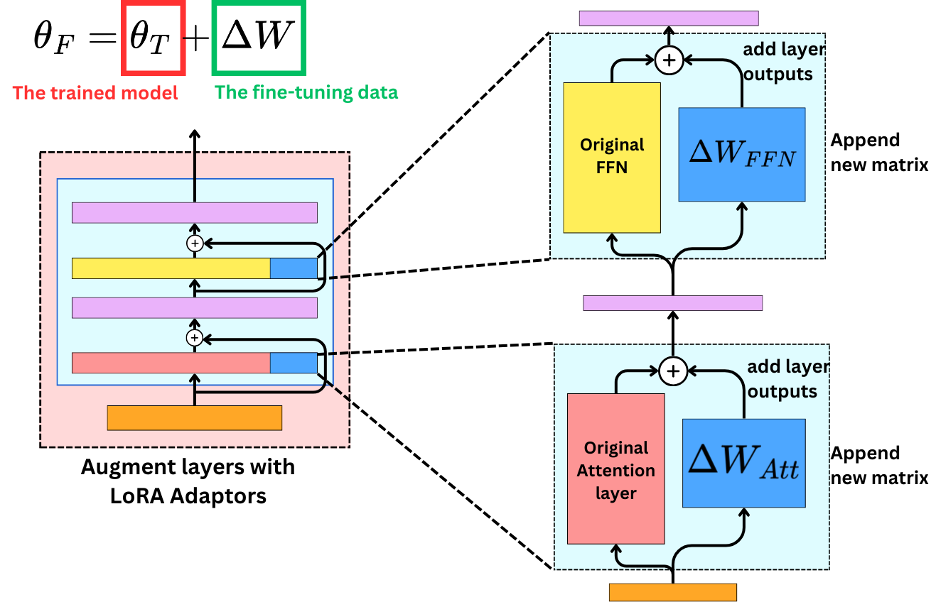


We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

This code applies LoRA (a PEFT technique) to fine-tune a large language model for specific tasks using less computation and memory. It modifies a limited part of the model architecture (target_modules) using small adapter matrices (with a specified rank), controls their influence with lora_alpha, and further optimizes the memory footprint with Unsloth. The other options are configurable for even more flexibility and potential memory savings.

In [ ]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # Turn off for just text!
    finetune_language_layers   = True,  # Should leave on!
    finetune_attention_modules = True,  # Attention good for GRPO
    finetune_mlp_modules       = True,  # Should leave on always!

    r = 8,           # Larger = higher accuracy, but might overfit
    lora_alpha = 8,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)

### LORA Parameters:

* model = FastModel.get_peft_model(...): This line calls the get_peft_model method to create the fine-tuned model and assigns it to the model variable. The original model (model) is passed as input.

* r = 8: This is the rank of the LoRA adapters. It controls the size of the trainable parameters. The higher the rank, the larger the fine-tuning model will be. Values like 8, 16, 32, 64, and 128 are recommended.

* finetune_vision_layers, finetune_language_layers,finetune_attention_modules, finetune_mlp_modules: This defines the layers within the original model that will be modified during fine-tuning. LoRA inserts small adapter modules into these target layers. In this case, the code targets various projection modules within attention layers.

* lora_alpha = 8: This is the scaling factor for the LoRA updates. It determines the impact of the adapter modules on the original model's outputs.

* lora_dropout = 0: This sets the dropout rate for the LoRA adapters, which helps prevent overfitting. It is optimized with a value of 0.

* bias = "none": This determines whether to add bias terms to the LoRA adapters. It is optimized with a value of "none."

* use_gradient_checkpointing = "unsloth": This employs a technique called gradient checkpointing (Unsloth implementation) that optimizes memory consumption during training. It's very useful for models with long context lengths. Setting it to True or "unsloth" enables it.

* random_state = 3407: This sets a seed value for random processes to ensure reproducibility.

<a name="Data"></a>
### Data Prep
We now use the `Gemma-4` format for conversation style finetunes. We use [Maxime Labonne's FineTome-100k](https://huggingface.co/datasets/mlabonne/FineTome-100k) dataset in ShareGPT style. Gemma-4 renders multi turn conversations like below:

```
<bos><|turn>user
Hello<turn|>
<|turn>model
Hey there!<turn|>
```
We use our `get_chat_template` function to get the correct chat template. We support `zephyr, chatml, mistral, llama, alpaca, vicuna, vicuna_old, phi3, llama3, phi4, qwen2.5, gemma3, gemma-4` and more.

In [ ]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-4",
)

## Get a HF dataset

In [ ]:
from datasets import load_dataset
dataset = load_dataset("mlabonne/FineTome-100k", split = "train[:1000]")

README.md:   0%|          | 0.00/982 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_dataset
nutuk_dataset = load_dataset("kmkarakaya/nutuk_soru_cevap", split = "train[:1000]")

README.md: 0.00B [00:00, ?B/s]

all.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4300 [00:00<?, ? examples/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Colab Notebooks/Nutuk_FineTune

/content/drive/MyDrive/Colab Notebooks/Nutuk_FineTune


## Get a local dataset

In [ ]:
# load the dataset from the local drive  csv file

import pandas as pd

# Replace 'your_file.csv' with the actual name of your CSV file
df = pd.read_csv('all.csv')

# Now you can work with the DataFrame 'df'
print(df.head())

                                            question  \
0  Vilâyât-ı Şarkiye Müdafaa-i Hukuk-ı Milliye Ce...   
1  Mavri Mira Heyeti'nin amaçları nelerdi ve nası...   
2  3. Ordu Müfettişi'nin yetkileri neleri kapsıyo...   
3  Metinde bahsedilen Pontus Cemiyeti'nin faaliye...   
4  İtilaf Devletleri'nin Osmanlı topraklarındaki ...   

                                              answer question_type  
0  Erzurum şubesi, Ermeni göçü sırasında görülen ...       Factual  
1  Mavri Mira Heyeti, İstanbul Rum Patrikhanesi'n...       Factual  
2  Müfettiş, iki kolorduya doğrudan emir verebili...       Factual  
3  Pontus Cemiyeti, Trabzon, Samsun ve Karadeniz ...       Factual  
4  İtilaf Devletleri'nin varlığı, Osmanlı toprakl...        Causal  


In [ ]:
# convert df to a datasets dataset

from datasets import Dataset

# Assuming 'df' is your pandas DataFrame
mydataset = Dataset.from_pandas(df, split = "train[:1000]")

# Now you can work with the 'dataset' object, which is a datasets Dataset
mydataset[100]

{'question': 'Eğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?',
 'answer': "Eğer Sivas Kongresi toplanmasaydı, Anadolu ve Rumeli'deki milli teşkilatlar birleşemeyecek,  milli mücadele daha dağınık ve zayıf bir şekilde yürütülecek,  İstanbul hükümetinin etkisinden kurtulma süreci daha zor ve uzun sürebilirdi.",
 'question_type': 'Hypothetical'}

In [ ]:
nutuk_dataset[100]

{'question': 'Eğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?',
 'answer': "Eğer Sivas Kongresi toplanmasaydı, Anadolu ve Rumeli'deki milli teşkilatlar birleşemeyecek,  milli mücadele daha dağınık ve zayıf bir şekilde yürütülecek,  İstanbul hükümetinin etkisinden kurtulma süreci daha zor ve uzun sürebilirdi.",
 'question_type': 'Hypothetical'}

In [ ]:
dataset[100]

{'conversations': [{'from': 'human',
   'value': 'What is the modulus operator in programming and how can I use it to calculate the modulus of two given numbers?'},
  {'from': 'gpt',
   'value': 'In programming, the modulus operator is represented by the \'%\' symbol. It calculates the remainder when one number is divided by another. To calculate the modulus of two given numbers, you can use the modulus operator in the following way:\n\n```python\n# Calculate the modulus\nModulus = a % b\n\nprint("Modulus of the given numbers is: ", Modulus)\n```\n\nIn this code snippet, the variables \'a\' and \'b\' represent the two given numbers for which you want to calculate the modulus. By using the modulus operator \'%\', we calculate the remainder when \'a\' is divided by \'b\'. The result is then stored in the variable \'Modulus\'. Finally, the modulus value is printed using the \'print\' statement.\n\nFor example, if \'a\' is 10 and \'b\' is 4, the modulus calculation would be 10 % 4, which e

We now use `standardize_data_formats` to try converting datasets to the correct format for finetuning purposes!

In [ ]:
from unsloth import to_sharegpt

nutuk_dataset = to_sharegpt(
    nutuk_dataset,
    merged_prompt="[[{question}]]",
    output_column_name="answer",

)

Merging columns:   0%|          | 0/1000 [00:00<?, ? examples/s]

Converting to ShareGPT:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
nutuk_dataset[100]

{'conversations': [{'from': 'human',
   'value': 'Eğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?'},
  {'from': 'gpt',
   'value': "Eğer Sivas Kongresi toplanmasaydı, Anadolu ve Rumeli'deki milli teşkilatlar birleşemeyecek,  milli mücadele daha dağınık ve zayıf bir şekilde yürütülecek,  İstanbul hükümetinin etkisinden kurtulma süreci daha zor ve uzun sürebilirdi."}]}

In [ ]:
from unsloth.chat_templates import standardize_data_formats
dataset = standardize_data_formats(dataset)
nutuk_dataset = standardize_data_formats(nutuk_dataset)

Unsloth: Standardizing formats (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

Unsloth: Standardizing formats (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
dataset[100]

{'conversations': [{'content': 'What is the modulus operator in programming and how can I use it to calculate the modulus of two given numbers?',
   'role': 'user'},
  {'content': 'In programming, the modulus operator is represented by the \'%\' symbol. It calculates the remainder when one number is divided by another. To calculate the modulus of two given numbers, you can use the modulus operator in the following way:\n\n```python\n# Calculate the modulus\nModulus = a % b\n\nprint("Modulus of the given numbers is: ", Modulus)\n```\n\nIn this code snippet, the variables \'a\' and \'b\' represent the two given numbers for which you want to calculate the modulus. By using the modulus operator \'%\', we calculate the remainder when \'a\' is divided by \'b\'. The result is then stored in the variable \'Modulus\'. Finally, the modulus value is printed using the \'print\' statement.\n\nFor example, if \'a\' is 10 and \'b\' is 4, the modulus calculation would be 10 % 4, which equals 2. Theref

In [ ]:
nutuk_dataset[100]

{'conversations': [{'content': 'Eğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?',
   'role': 'user'},
  {'content': "Eğer Sivas Kongresi toplanmasaydı, Anadolu ve Rumeli'deki milli teşkilatlar birleşemeyecek,  milli mücadele daha dağınık ve zayıf bir şekilde yürütülecek,  İstanbul hükümetinin etkisinden kurtulma süreci daha zor ve uzun sürebilirdi.",
   'role': 'assistant'}]}

Let's see how row 100 looks like!

We now have to apply the chat template for `Gemma-4` onto the conversations, and save it to `text`. We remove the `<bos>` token using removeprefix(`'<bos>'`) since we're finetuning. The Processor will add this token before training and the model expects only one.

In [ ]:
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False).removeprefix('<bos>') for convo in convos]
   return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

nutuk_dataset = nutuk_dataset.map(formatting_prompts_func, batched = True)


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Let's see how the chat template did! Notice there is no `<bos>` token as the processor tokenizer will be adding one.

In [ ]:
dataset[100]["text"]

'<|turn>user\nWhat is the modulus operator in programming and how can I use it to calculate the modulus of two given numbers?<turn|>\n<|turn>model\nIn programming, the modulus operator is represented by the \'%\' symbol. It calculates the remainder when one number is divided by another. To calculate the modulus of two given numbers, you can use the modulus operator in the following way:\n\n```python\n# Calculate the modulus\nModulus = a % b\n\nprint("Modulus of the given numbers is: ", Modulus)\n```\n\nIn this code snippet, the variables \'a\' and \'b\' represent the two given numbers for which you want to calculate the modulus. By using the modulus operator \'%\', we calculate the remainder when \'a\' is divided by \'b\'. The result is then stored in the variable \'Modulus\'. Finally, the modulus value is printed using the \'print\' statement.\n\nFor example, if \'a\' is 10 and \'b\' is 4, the modulus calculation would be 10 % 4, which equals 2. Therefore, the output of the above code

In [ ]:
nutuk_dataset[100]["text"]

"<|turn>user\nEğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?<turn|>\n<|turn>model\nEğer Sivas Kongresi toplanmasaydı, Anadolu ve Rumeli'deki milli teşkilatlar birleşemeyecek,  milli mücadele daha dağınık ve zayıf bir şekilde yürütülecek,  İstanbul hükümetinin etkisinden kurtulma süreci daha zor ve uzun sürebilirdi.<turn|>\n"

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [ ]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = nutuk_dataset,
    eval_dataset = None, # Can set up evaluation!
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4, # Use GA to mimic batch size!
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 60,
        learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs. This helps increase accuracy of finetunes!

### Trainer Parameters:

**trainer = SFTTrainer(...)**: This is where the actual fine-tuning is set up. It's like creating a workout plan for the model.

**model = model**: The model we want to fine-tune.

**tokenizer = tokenizer**: A helper tool that breaks text down into smaller pieces for the model to understand.

**train_dataset = mydataset**: The data we'll use to teach the model, like a collection of examples.

**dataset_text_field = "text"**: Telling the trainer where the text is located in the dataset.

**max_seq_length = max_seq_length**: Limiting the length of text the model processes at once.

**dataset_num_proc = 2**: Using 2 processes to prepare the data faster.

**args = TrainingArguments(...)**: This is where the training instructions are specified:
* **per_device_train_batch_size = 2**: How many examples the model sees at once during training.
* **gradient_accumulation_steps = 4**: Like delaying changes to the model for a few steps to make them more meaningful.
* **warmup_steps =**: Gradually increasing the learning rate (how fast the model learns) in the beginning.
* **max_steps =**: Total number of training steps.
* **learning_rate =**: How fast the model learns.
* **fp16 and bf16**: Settings to make calculations faster and use less memory.
* **logging_steps =**: How often to show progress updates during training.
* **optim =**: A method used to update the model's parameters (weights).
* **weight_decay =**: A way to prevent the model from learning things that aren't useful.
* **lr_scheduler_type = "linear"**: How the learning rate changes over time.
* **seed = 3407**: Setting a value for random processes to make training results reproducible.

* **report_to = "none"**: Not reporting progress to any external tool.

In [ ]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|turn>user\n",
    response_part = "<|turn>model\n",
)

Map (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

Let's verify masking the instruction part is done! Let's print the 100th row again.  Notice how the sample only has a single `<bos>` as expected!

In [ ]:
tokenizer.decode(trainer.train_dataset[100]["input_ids"])

"<|turn>user\nEğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?<turn|>\n<|turn>model\nEğer Sivas Kongresi toplanmasaydı, Anadolu ve Rumeli'deki milli teşkilatlar birleşemeyecek,  milli mücadele daha dağınık ve zayıf bir şekilde yürütülecek,  İstanbul hükümetinin etkisinden kurtulma süreci daha zor ve uzun sürebilirdi.<turn|>\n"

Now let's print the masked out example - you should see only the answer is present:

In [ ]:
tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.train_dataset[100]["labels"]]).replace(tokenizer.pad_token, " ")

"                             Eğer Sivas Kongresi toplanmasaydı, Anadolu ve Rumeli'deki milli teşkilatlar birleşemeyecek,  milli mücadele daha dağınık ve zayıf bir şekilde yürütülecek,  İstanbul hükümetinin etkisinden kurtulma süreci daha zor ve uzun sürebilirdi.<turn|>\n"

In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
8.014 GB of memory reserved.


# Let's train the model!

To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 12,668,928 of 5,135,846,944 (0.25% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Step,Training Loss
1,15.936698
2,16.463831
3,16.656626
4,16.663513
5,16.084309
6,16.913410
7,16.633373
8,16.362560
9,16.086185
10,15.428328


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

262.021 seconds used for training.
4.37 minutes used for training.
Peak reserved memory = 8.014 GB.
Peak reserved memory for training = 0.0 GB.
Peak reserved memory % of max memory = 55.03 %.
Peak reserved memory for training % of max memory = 0.0 %.


<a name="Inference"></a>
## Inference
Let's run the model via Unsloth native inference! According to the `Gemma-4` team, the recommended settings for inference are `temperature = 1.0, top_p = 0.95, top_k = 64`

In [ ]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-4",
)
messages = [{
    "role": "user",
    "content": [{
        "type" : "text",
        "text" : "Eğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?",
    }]
}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
    tokenize = True,
    return_dict = True,
).to("cuda")
outputs = model.generate(
    **inputs,
    max_new_tokens = 256, # Increase for longer outputs!
    # Recommended Gemma-4 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
)
tokenizer.batch_decode(outputs)

["<bos><|turn>user\nEğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?<turn|>\n<|turn>model\nSivas Kongresi'nin toplanmaması durumunda, Osmanlı İmparatorluğu'nun ve Milli Mücadele'nin kaderi üzerinde çok ciddi ve farklı sonuçlar ortaya çıkabilirdi. Bu kongre, sadece bir toplantı olmaktan öte, ulusal bir bilinç oluşturma, merkezi bir yönetim anlayışı geliştirme ve uluslararası alanda bağımsızlık talebini resmileştirme açısından kritik bir dönüm noktasıydı.\n\nİşte Sivas Kongresi'nin toplanmaması durumunda ortaya çıkabilecek potansiyel sonuçlar:\n\n---\n\n### 1. Ulusal Birliğin ve Milli Bilincin Zayıflaması\n\n**Mevcut Durum:** Sivas Kongresi, farklı bölgelerden gelen temsilcileri tek bir çatı altında toplayarak, Anadolu'daki farklı milletleri (Türk, Kürt, Alevi vb.) ortak bir mücadele ruhu etrafında birleştirmeyi amaçladı.\n\n**Eğer Toplanmasaydı:**\n* **Parçalanma Riski:** Bölgesel direnişler, ulusal bir strateji oluşturmakta zorlanabilir ve her bölge kendi çıkarla

 You can also use a `TextStreamer` for continuous inference - so you can see the generation token by token, instead of waiting the whole time!

In [ ]:
messages = [{
    "role": "user",
    "content": [{"type" : "text", "text" : "Eğer Sivas Kongresi toplanmasaydı, ne gibi sonuçlar ortaya çıkabilirdi?",}]
}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
    tokenize = True,
    return_dict = True,
).to("cuda")

from transformers import TextStreamer
_ = model.generate(
    **inputs,
    max_new_tokens = 256, # Increase for longer outputs!
    # Recommended Gemma-4 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

Sivas Kongresi'nin toplanmaması, Osmanlı İmparatorluğu'nun ve Türk milletinin kaderinde çok ciddi ve karmaşık sonuçlar doğurabilecek, çok boyutlu bir senaryodur. Bu kongre, sadece siyasi bir toplantı olmanın ötesinde, Milli Mücadele'nin stratejik ve ideolojik temelini atmış, ulusal bağımsızlık mücadelesinin bir dönüm noktası olmuştur.

İşte Sivas Kongresi'nin toplanmaması durumunda ortaya çıkabilecek olası sonuçlar:

---

## 1. Milli Mücadele'nin Organizasyonel ve Stratejik Bozulması

Sivas Kongresi, Milli Mücadele'nin merkezi bir karar alma ve organize olma platformuydu.

* **Merkeziyetin Kaybı ve Dağınıklık:** Kongre, farklı cephelerden gelen (asker, siyasetçi, kadın, milis) temsilcilerin tek bir çatı altında toplanmasını sağlayarak, ulusal bir strateji oluşturulmasını sağladı. Kongre olmasaydı, farklı grupların kendi çıkarlarını takip etmesi, koordinasyon eksikliğine ve stratejik tutarsızlığa yol


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("gemma_4_lora_nutuk")  # Local saving
tokenizer.save_pretrained("gemma_4_lora_nutuk")
# model.push_to_hub("HF_ACCOUNT/gemma_4_lora_nutuk", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("HF_ACCOUNT/gemma_4_lora_nutuk", token = "YOUR_HF_TOKEN") # Online saving

['gemma_4_lora_nutuk/processor_config.json']

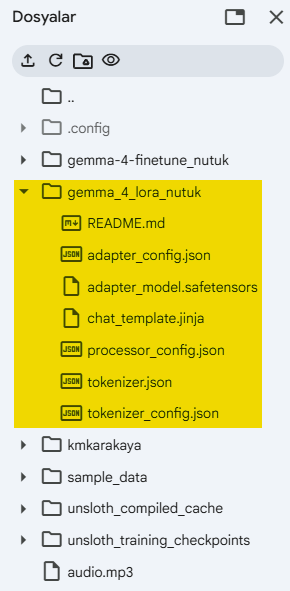

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastModel
    model, tokenizer = FastModel.from_pretrained(
        model_name = "gemma_4_lora_nutuk", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = 128,
        load_in_4bit = True,
    )

messages = [{
    "role": "user",
    "content": [{"type" : "text", "text" : "What is Gemma-4?",}]
}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
    tokenize = True,
    return_dict = True,
).to("cuda")

from transformers import TextStreamer
_ = model.generate(
    **inputs,
    max_new_tokens = 128, # Increase for longer outputs!
    # Recommended Gemma-4 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

Gemma 4 is a family of lightweight, state-of-the-art open models developed by Google DeepMind.

Here are some key things to know about Gemma 4:

* **Open Weights:** As an open model, the weights of the models in the Gemma family are publicly available, allowing researchers and developers to build upon, fine-tune, and deploy them for a wide variety of applications.
* **Model Family:** Gemma 4 represents a series of models designed for performance across various tasks, often optimized for efficiency and accessibility.
* **Capabilities:** Like other large language models, Gemma 4 is capable


### Saving to float16 for VLLM

We also support saving to `float16` directly for deployment! We save it in the folder `gemma-4-finetune`. Set `if False` to `if True` to let it run!

In [ ]:
if True: # Change to True to save finetune!
    model.save_pretrained_merged("gemma-4-finetune_nutuk", tokenizer)

NameError: name 'model' is not defined

If you want to upload / push to your Hugging Face account, set `if False` to `if True` and add your Hugging Face token and upload location!

In [ ]:
if False: # Change to True to upload finetune
    from google.colab import userdata
    model.push_to_hub_merged(
        "kmkarakaya/gemma-4-finetune_nutuk", tokenizer,
        token = userdata.get('HF_TOKEN') # Get the token from Colab Secrets
    )


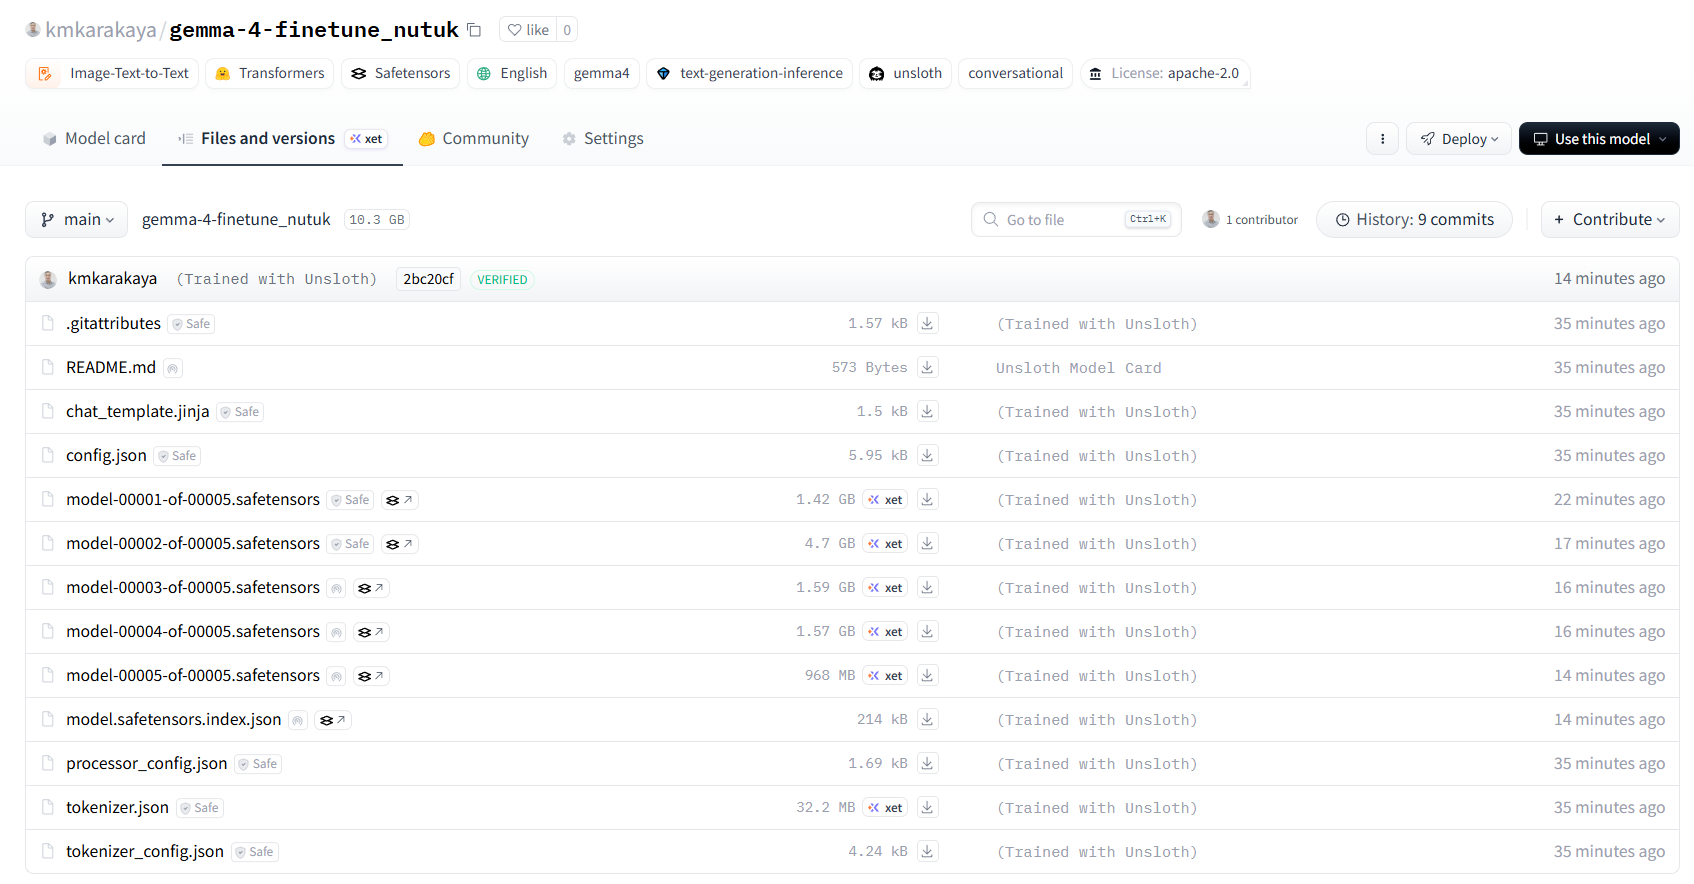
  


### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now for all models! For now, you can convert easily to `Q8_0, F16 or BF16` precision. `Q4_K_M` for 4bit will come later!

In [ ]:
if True: # Change to True to save to GGUF
    model.save_pretrained_gguf(
        "gemma_4_finetune_nutuk_GGUF",
        tokenizer,
        quantization_method = "Q8_0", # For now only Q8_0, BF16, F16 supported
    )

Unsloth: Merging model weights to 16-bit format...
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...


RuntimeError: Unsloth: GGUF conversion failed: Unsloth: `gemma_4_finetune_nutuk_GGUF` does not exist?

Likewise, if you want to instead push to GGUF to your Hugging Face account, set `if False` to `if True` and add your Hugging Face token and upload location!

In [ ]:
if True: # Change to True to upload GGUF
    from google.colab import userdata
    model.push_to_hub_gguf(
        "kmkarakaya/gemma_4_finetune_nutuk_GGUF",
        tokenizer,
        quantization_method = "Q8_0", # Only Q8_0, BF16, F16 supported
        token = userdata.get('HF_TOKEN'), # Get the token from Colab Secrets
    )

Unsloth: Converting model to GGUF format...
Unsloth: Merging model weights to 16-bit format...
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...


RuntimeError: Failed to convert model to GGUF: Unsloth: GGUF conversion failed: Unsloth: `config.json` does not exist inside `/tmp/unsloth_gguf_99zqe80w`.